# Smart Contract Vulnerability Detection: Data Preprocessing

This notebook handles the end-to-end preprocessing pipeline for the SmartBug dataset. The goal is to prepare Solidity source code for training with a Transformer model (CodeBERT), specifically focusing on line-level vulnerability localization.

Dataset from: https://www.kaggle.com/datasets/tranduongminhdai/smartbug-dataset/data

Solidity preprocessing code adapted from : https://www.kaggle.com/code/mestaysserasma/ai-driven-smart-contract-vulnerability-detection

### Key Steps:
1. **Data Loading**: Importing the raw dataset from Google Drive.
2. **Sampling**: Addressing severe class imbalance (94% vulnerable vs 6% safe).
3. **Cleaning**: Sanitizing Solidity code while preserving line numbers.
4. **Chunking**: Splitting long contracts into 512-token segments with a sliding window.
5. **Label Alignment**: Mapping global vulnerability line numbers to specific code chunks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Acquisition & Initial Loading
Mounting Drive and loading the master CSV containing contract addresses, source code, and expert-labeled vulnerability lines.

In [ ]:
# Run once:
#import os
## Change this to the folder in your Drive where you saved kaggle.json

#os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/Kaggle"
#!mkdir -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data"

## Download dataset to drive
#!kaggle datasets download -d tranduongminhdai/smartbug-dataset -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data" --unzip

In [ ]:
import pandas as pd

csv_path = "/content/drive/My Drive/CPSC440_project/data/smartbug_data/smartbugs_final_ver.csv"
df = pd.read_csv(csv_path)

In [ ]:
df

,Unnamed: 0,address,tools,lines,nb_vulnerabilities,source_code,labels
0,0,0x8d12a197cb00d4747a1fe03395095ce2a5cc6819,"{'mythril': {'vulnerabilities': {}, 'categorie...","[32, 229, 38, 136, 268, 45, 51, 254, 56, 28, 2...",15.0,pragma solidity ^0.4.9;\n\ncontract SafeMath {...,unknow
1,1,0x2a0c0dbecc7e4d658f48e01e3fa353f44050c208,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[163, 36, 101, 133, 110, 145, 122, 127]",10.0,pragma solidity ^0.4.16;\n\ncontract Token {\n...,reentrancy
2,2,0x174bfa6600bf90c885c7c01c7031389ed1461ab9,"{'mythril': {'vulnerabilities': {}, 'categorie...",[],0.0,pragma solidity >=0.4.22 <0.6.0;\n\ncontract o...,clean
3,3,0x06012c8cf97bead5deae237070f9587f8e7a266d,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[769, 1414, 1287, 1686, 1175, 1048, 1817, 924,...",82.0,pragma solidity ^0.4.11;\n\n\n/**\n * @title O...,arithmetic
4,4,0x86fa049857e0209aa7d9e616f7eb3b3b78ecfdb0,"{'mythril': {'vulnerabilities': {}, 'categorie...",[115],1.0,contract DSNote {\n event LogNote(\n ...,arithmetic
...,...,...,...,...,...,...,...
47326,47446,0x000000eade0fe9269d0412a6055b6f3c5d968488,{'mythril': {'vulnerabilities': {'Message call...,"[47, 49, 51, 52, 54, 56]",6.0,pragma solidity ^0.4.23;\n\n// File: contracts...,reentrancy
47327,47447,0x000000d4e883e304c7f9574ebeecf238eb55a40f,"{'mythril': {'vulnerabilities': {}, 'categorie...",[24],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47328,47448,0x000000961d1ac83a67d0ce61612b36f18c10c9b7,"{'mythril': {'vulnerabilities': {}, 'categorie...",[26],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47329,47449,0x00000000e82eb0431756271f0d00cfb143685e7b,"{'mythril': {'vulnerabilities': {}, 'categorie...","[4069, 4029]",2.0,pragma solidity 0.5.6;\n\n\n/**\n * @title Met...,access_control


In [ ]:
df.shape

(47331, 7)

In [ ]:
df["labels"].value_counts()

,count
labels,
arithmetic,26645
reentrancy,5225
unknow,4508
front_running,3251
denial_service,2875
clean,2742
unchecked_low_calls,1131
access_control,591
time_manipulation,363


In [ ]:
shortest_contract_index = df['source_code'].apply(len).idxmin()
shortest_contract = df.loc[shortest_contract_index]
shortest_contract['source_code']
shortest_contract

,43569
Unnamed: 0,43674
address,0x7222af88c86620651a5594204d1f5305b1a5671f
tools,"{'mythril': {'vulnerabilities': {}, 'categorie..."
lines,[]
nb_vulnerabilities,0.0
source_code,contract Eater{\n\tfunction(){\n\t\t\n\t}\n}
labels,clean


In [ ]:
df["is_vulnerable"] = df['nb_vulnerabilities'] > 0

In [ ]:
df["is_vulnerable"].value_counts()

,count
is_vulnerable,
True,44589
False,2742


## 2. Strategic Downsampling
The dataset is heavily skewed toward vulnerable contracts. We use **Stratified Sampling** to reduce the number of vulnerable samples to 12k while maintaining the distribution of specific vulnerability types (e.g., reentrancy, arithmetic), ensuring the model sees enough 'Clean' examples.

Because there is a serious class imbalance between the vulnerable vs safe smart contracts, we chose to downsample the vulenrable contracts through stratified sampling to 12K samples.

In [ ]:
import ast
def has_valid_vuln_line(row):
    if not row["is_vulnerable"]:
        return True

    raw = row["lines"]

    if isinstance(raw, str):
        raw = ast.literal_eval(raw)

    if raw and isinstance(raw[0], list):
        raw = [x for sub in raw for x in sub]

    if not raw:
        return False

    source_len = len(str(row["source_code"]).split("\n"))

    # keep if ANY label is plausible
    for v in raw:
        if isinstance(v, (int, float)):
            if 0 <= int(v) < source_len:
                return True
            if 1 <= int(v) <= source_len:
                return True

    return False


df = df[df.apply(has_valid_vuln_line, axis=1)].copy()

In [ ]:
df_vulnerable = df[df['is_vulnerable'] == True]
df_safe = df[df['is_vulnerable'] == False]

target_vuln_size = 12_000
df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(
    lambda x: x.sample(
        n=min(len(x), int(target_vuln_size * len(x) / len(df_vulnerable))),
        random_state=32
    )
)

# Combine back with all your clean samples
df_curated = pd.concat([df_vulnerable_sampled, df_safe]).sample(frac=1, random_state=32).reset_index(drop=True)

/tmp/ipykernel_38256/4015686408.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(


In [ ]:
# get rid of the ambiguous vulnerability smart contracts:
df_clean = df_curated[df_curated['labels'] != 'unknow'].copy()
challenge_eval_df = df_curated[df_curated['labels'] == 'unknow'].copy()

In [ ]:
print(df_clean.shape)
print(challenge_eval_df.shape)

(13528, 8)
(1210, 8)


In [ ]:
df_clean["labels"].value_counts()

,count
labels,
arithmetic,7187
clean,2742
reentrancy,1408
front_running,870
denial_service,775
unchecked_low_calls,305
access_control,144
time_manipulation,97


/tmp/ipykernel_38256/3738891875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


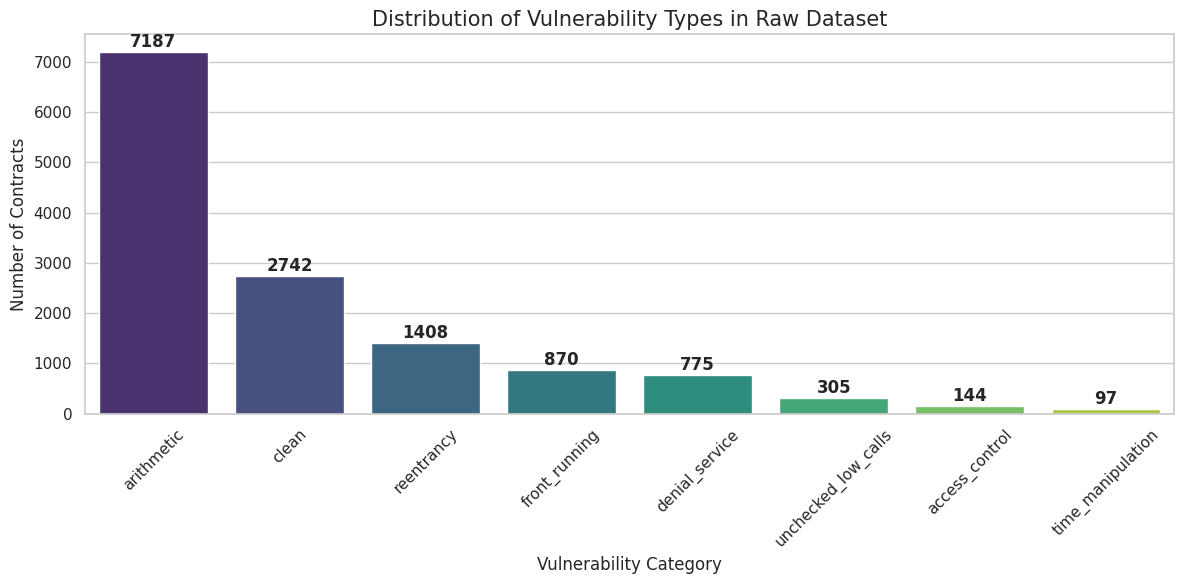

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic report
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Use the value counts from your df_clean
label_counts = df_clean['labels'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title('Distribution of Vulnerability Types in Raw Dataset', fontsize=15)
plt.xlabel('Vulnerability Category', fontsize=12)
plt.ylabel('Number of Contracts', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300)
plt.show()

In [ ]:
df_clean['labels'].isnull().sum()

np.int64(0)

In [ ]:
import re
# Keywords and known non-user-defined functions of Solidity
keywords = frozenset({
    # Data Types
    'bool', 'int', 'uint', 'string', 'bytes', 'enum', 'struct', 'mapping', 'bytes4', 'bytes32',

    # keywords
    'pragma', 'solidity', 'contract', 'library', 'interface', 'function', 'modifier', 'event',
    'if', 'else', 'while', 'for', 'do', 'break', 'continue', 'return',
    'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert', 'require',
    'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # Ethereum specific
    'msg', 'sender', 'value', 'block', 'timestamp', 'gas', 'this', 'super',

    # Solidity concepts
    'payable', 'constructor', 'indexed', 'case', 'catch', 'const', 'default',
    'float', 'long', 'noReentrancy', 'super', 'or', 'protected', 'noReentrancy',
    'returns', 'event', 'emit', 'export', 'extern', 'false', 'throw', 'true', 'try',
    'union', 'NULL', 'notConfirmed', 'onlyOwner', 'onlyGovernor', 'onlyCommittee',
    'onlyAdmin', 'onlyPlayers', 'ownerExists', 'onlyManager', 'onlyHuman', 'only_owner',
    'onlyCongressMembers', 'preventReentry', 'noEther', 'onlyMembers', 'onlyProxyOwner',
    'confirmed', 'notExecuted', 'assert', 'switch', 'preventReentry',
    'return', 'returns', 'constructor', 'indexed', 'pragma', 'solidity', 'contract', 'library',
    'interface', 'function', 'modifier', 'event', 'if', 'else', 'while', 'for', 'do', 'break',
    'continue', 'return', 'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert',
    'require', 'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # built in fns
    'selfdestruct', 'delegatecall', 'call', 'callcode', 'staticcall', 'create', 'create2',
    'keccak256', 'sha256', 'ripemd160', 'ecrecover', 'addmod', 'mulmod', 'balance', 'extcodesize',
    'extcodecopy', 'codesize', 'codecopy', 'gasleft', 'log0', 'log1', 'log2', 'log3', 'log4',

    # arithmetic + logic
    'add', 'sub', 'mul', 'div', 'mod', 'exp', 'iszero', 'lt', 'gt', 'eq', 'ne', 'and', 'or', 'not', 'xor',

    # state change
    'send', 'transfer', 'approve', 'transferFrom', 'mint', 'burn', 'mintTo', 'burnFrom', 'balanceOf',
    'owner', 'onlyOwner', 'isOwner', 'Transfer', 'Transaction',

    # others,,,
    'switch', 'pure', 'selfdestruct', 'view', 'this', 'union', 'constant', 'mapping'
})


main_set = frozenset({'function', 'constructor', 'modifier', 'contract'})
main_args = frozenset({'argc', 'argv'})

def remove_version(contract_text):
    return re.sub(r'pragma solidity\s+\^?\d+\.\d+\.\d+;', '', contract_text)

def remove_comments_and_non_ascii(contract):
    contract = re.sub(r'\/\*[\s\S]*?\*\/|\/\/[^\n]*', '', contract)
    contract = re.sub(r'//.*?\n|/\*.*?\*/', '',contract, flags=re.S)
    contract = re.sub(r'[^\x00-\x7F]+', '', contract)
    return contract

def remove_blank_lines(contract):
    return '\n'.join(line for line in contract.split('\n') if line.strip())

def clean_solidity_code_line_preserved(contract_text):
    #  replace pragma version with blank spaces
    contract_text = re.sub(r'pragma solidity\s+\^?\d+\.\d+\.\d+;', ' ', contract_text)

    # replace single line comments
    contract_text = re.sub(r'//[^\n]*', ' ', contract_text)

    # replace multi-line comments with \n
    def replace_multiline(match):
        return '\n' * match.group(0).count('\n')
    contract_text = re.sub(r'/\*[\s\S]*?\*/', replace_multiline, contract_text)

    # remove non ascii chars
    contract_text = re.sub(r'[^\x00-\x7F]+', ' ', contract_text)

    return contract_text

## 3. Solidity Code Sanitization
We define a specialized cleaner that removes non-ASCII characters and comments.

**Note:** We use `clean_solidity_code_line_preserved` to ensure that line indices remain consistent with the original ground truth labels, replacing comments with whitespace rather than deleting them.

In [ ]:
df_clean = df_clean.rename(columns={"Unnamed: 0": "contract_id"})
df_clean['contract_id']

,contract_id
0,7784
1,31795
3,46094
5,22470
6,26808
...,...
14731,14386
14732,972
14733,23793
14735,12922


Drop duplicates



In [ ]:
df_clean['cleaned_contract'] = df_clean['source_code'].apply(clean_solidity_code_line_preserved)
df_clean = df_clean.drop_duplicates(subset=['cleaned_contract'])
df_clean = df_clean.reset_index(drop=True)

Determine number of tokens per contract

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
def get_token_length(code):
    return len(tokenizer(code, add_special_tokens=False)["input_ids"])

df_clean['token_len'] = df_clean['cleaned_contract'].apply(get_token_length)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (1497 > 512). Running this sequence through the model will result in indexing errors


## 4. Token Length Analysis
CodeBERT has a maximum sequence length of 512 tokens. Most smart contracts exceed this limit, requiring us to implement a chunking strategy.

In [ ]:
# see proportion of long contracts that are too long
df_long = df_clean[df_clean['token_len'] > 512].copy()
long_dist = df_long.groupby('is_vulnerable').size().reset_index(name='count')
total_long = len(df_long)
long_dist['percentage'] = (long_dist['count'] / total_long) * 100

print("Distribution of Long Contracts (>512 tokens):")
print(long_dist)

Distribution of Long Contracts (>512 tokens):
   is_vulnerable  count  percentage
0          False   2406   18.852844
1           True  10356   81.147156


94.60340993328391


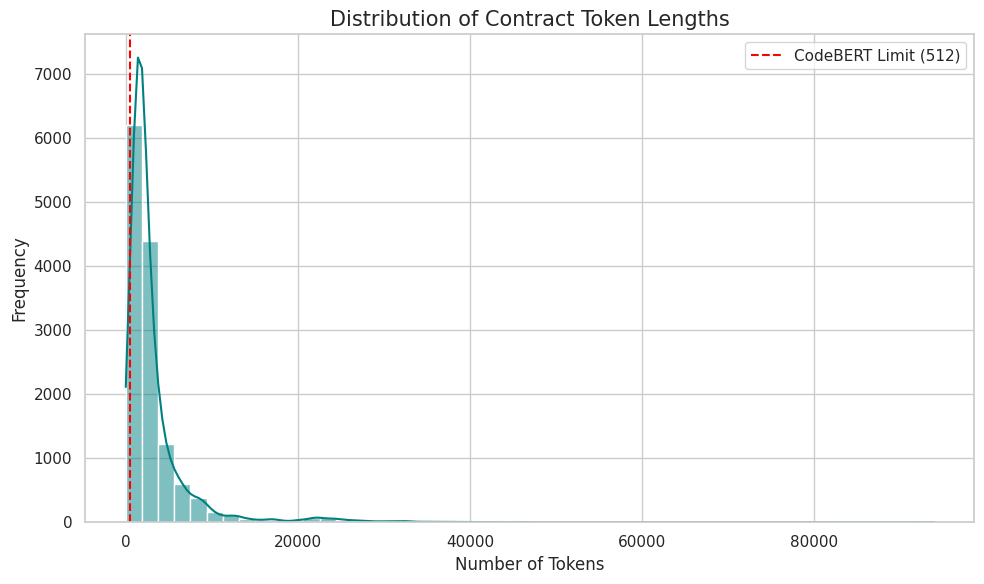

In [ ]:
plt.figure(figsize=(10, 6))

# plot histogram of the token_len column you already created
sns.histplot(df_clean['token_len'], bins=50, kde=True, color='teal')

# draw a vertical line at the 512 mark
plt.axvline(x=512, color='red', linestyle='--', label='CodeBERT Limit (512)')

plt.title('Distribution of Contract Token Lengths', fontsize=15)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# annotate the percentage of data over the limit
over_limit = (df_clean['token_len'] > 512).mean() * 100
print(over_limit)

plt.tight_layout()
plt.savefig('token_length_dist.png', dpi=300)
plt.show()

Split data


In [ ]:
import ast
# Pre-parse the strings into Python lists once
df_clean['lines'] = df_clean['lines'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
# splitting:
from sklearn.model_selection import train_test_split
seed = 32
temp_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean['is_vulnerable'],
    random_state=seed
)


train_df, val_df = train_test_split(
    temp_df,
    test_size=0.25,
    stratify=temp_df['is_vulnerable'],
    random_state=seed
)

In [ ]:
train_vulnerable = train_df[train_df['is_vulnerable'] == True]
train_safe = train_df[train_df['is_vulnerable'] == False]

def custom_sample(group):
  # ignore minority class:
  if len(group) <= 500:
      return group

  frac = min(1.0, 3000 / len(group))
  return group.sample(frac=frac, random_state=seed)

# resample to balance
train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)

# recombine
train_df_final = pd.concat([train_vulnerable_sampled, train_safe]).sample(frac=1, random_state=seed)

/tmp/ipykernel_38256/2945608028.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)


In [ ]:
train_df_final["labels"].value_counts()
train_df["labels"].value_counts()

,count
labels,
arithmetic,4318
clean,1631
reentrancy,854
front_running,508
denial_service,457
unchecked_low_calls,179
access_control,85
time_manipulation,62


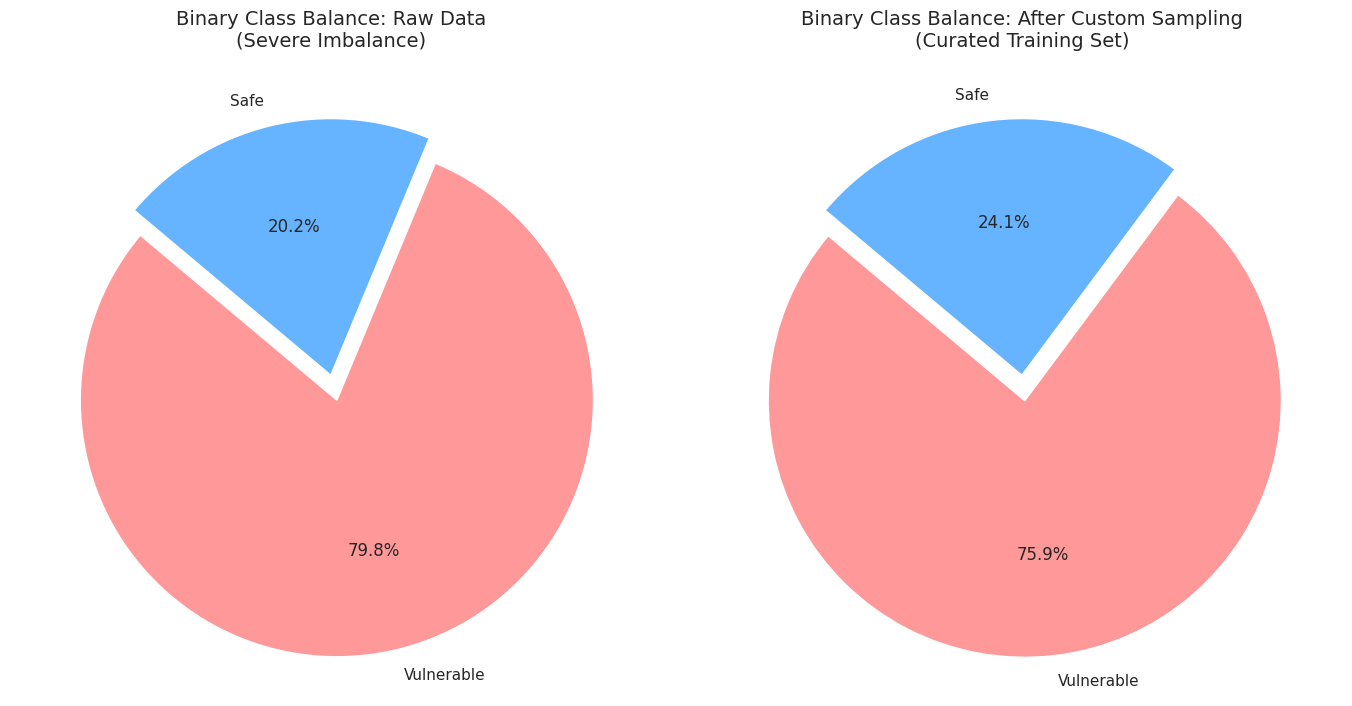

In [ ]:
# show pie chart of the difference in distribution of samples before and after sampling
before_counts = df_clean['is_vulnerable'].value_counts()
after_counts = train_df_final['is_vulnerable'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Red == Vulnerable, Green == Safe
colors = ['#ff9999','#66b3ff']
labels = ['Vulnerable', 'Safe']

# before
ax1.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax1.set_title('Binary Class Balance: Raw Data\n(Severe Imbalance)', fontsize=14)

# after
ax2.pie(after_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax2.set_title('Binary Class Balance: After Custom Sampling\n(Curated Training Set)', fontsize=14)

plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=300)
plt.show()

## 5. Contract Chunking & Smart Sampling
To handle long contracts, we split them into chunks. During training, we use `smart_sample_contract` to ensure that for every vulnerable contract, at least one chunk containing the actual bug is included in the training batch.

In [ ]:
print(f"Training: {train_df_final.shape}\n{train_df['is_vulnerable'].value_counts()}")
print(f"Validation: {val_df.shape}\n{val_df['is_vulnerable'].value_counts()}")
print(f"Test: {test_df.shape}\n{test_df['is_vulnerable'].value_counts()}")

Training: (6776, 10)
is_vulnerable
True     6463
False    1631
Name: count, dtype: int64
Validation: (2698, 10)
is_vulnerable
True     2154
False     544
Name: count, dtype: int64
Test: (2698, 10)
is_vulnerable
True     2154
False     544
Name: count, dtype: int64


# Contract Processing into Chunks:

In [ ]:
mismatches = 0
import ast
for _, row in df_clean[df_clean['is_vulnerable'] == True].iterrows():
    source_lines = len(str(row['cleaned_contract']).split('\n'))
    vuln_lines = ast.literal_eval(row['lines']) if isinstance(row['lines'], str) else row['lines']

    if vuln_lines and isinstance(vuln_lines[0], list):
        vuln_lines = [item for sublist in vuln_lines for item in sublist]

    if any(l >= source_lines for l in vuln_lines):
        mismatches += 1

print(f"Contracts with suspicious label alignment: {mismatches}")

Contracts with suspicious label alignment: 1666


In [ ]:
def normalize_vuln_lines(raw_vuln_lines, source_line_count):
    """
    Strictly standardizes vulnerability lines to 0-based indexing.
    Filters out any line numbers that fall outside the physical code range.
    """
    if isinstance(raw_vuln_lines, list) and raw_vuln_lines and isinstance(raw_vuln_lines[0], list):
        vuln_lines = list(set(x for sub in raw_vuln_lines for x in sub))
    elif isinstance(raw_vuln_lines, list):
        vuln_lines = list(set(raw_vuln_lines))
    else:
        vuln_lines = []

    normalized = set()
    for v in vuln_lines:
        try:
            # Shift 1-based dataset to 0-based indices
            idx = int(v) - 1

            # CRITICAL FILTER: Only keep if the line actually exists in the source
            if 0 <= idx < source_line_count:
                normalized.add(idx)
            else:
                # This logs that a label was rejected because it points to nothing
                print(f"Skipping out-of-bounds label: {v} (Max lines: {source_line_count})")
        except (ValueError, TypeError):
            continue

    return normalized

In [ ]:
import random
def process_data(
    df,
    tokenizer,
    augmentor=None,
    max_len=512,
    stride=256,
    max_chunks=10,
    is_training=False
):
    processed_data = []

    for row in df.itertuples(index=False):
        source = str(row.source_code)
        cleaned_source = str(row.cleaned_contract)

        raw_lines = source.split("\n")
        source_line_count = len(raw_lines)

        # -----------------------------
        # 1. Normalize vulnerability lines
        # -----------------------------
        vuln_set = normalize_vuln_lines(row.lines, source_line_count)

        # -----------------------------
        # 2. Tokenize FULL contract with offsets (FIX #2)
        # -----------------------------
        enc = tokenizer(
            cleaned_source,
            return_offsets_mapping=True,
            add_special_tokens=False
        )

        input_ids = enc["input_ids"]
        offsets = enc["offset_mapping"]

        # Build line start positions
        line_starts = []
        pos = 0
        for line in cleaned_source.split("\n"):
            line_starts.append(pos)
            pos += len(line) + 1  # +1 for newline

        # Map each token → line index
        token_to_line = []
        current_line = 0

        for start, _ in offsets:
            while (
                current_line + 1 < len(line_starts)
                and start >= line_starts[current_line + 1]
            ):
                current_line += 1
            token_to_line.append(current_line)

        # -----------------------------
        # 3. Sliding window chunking
        # -----------------------------
        chunks = []
        start_idx = 0

        while start_idx < len(input_ids):
            end_idx = min(start_idx + max_len, len(input_ids))

            chunk_tokens = input_ids[start_idx:end_idx]
            chunk_line_map = token_to_line[start_idx:end_idx]
            unique_lines = sorted(set(chunk_line_map))

            chunks.append({
                "tokens": chunk_tokens,
                "line_indices": unique_lines
            })

            if end_idx == len(input_ids):
                break

            start_idx += stride

        # -----------------------------
        # 4. Training-time smart sampling
        # -----------------------------
        if is_training:
            vuln_indices = [
                idx for idx, c in enumerate(chunks)
                if set(c["line_indices"]) & vuln_set
            ]

            sampling_pool = set(vuln_indices)

            # add neighbors
            for idx in vuln_indices:
                if idx > 0:
                    sampling_pool.add(idx - 1)
                if idx < len(chunks) - 1:
                    sampling_pool.add(idx + 1)

            # ALWAYS include all vuln chunks first
            final_indices = list(vuln_indices)

            # then add others
            remaining = [i for i in sampling_pool if i not in vuln_indices]
            random.shuffle(remaining)

            for i in remaining:
                if len(final_indices) >= max_chunks:
                    break
                final_indices.append(i)

            # fill with random if needed
            if len(final_indices) < max_chunks:
                extra = [i for i in range(len(chunks)) if i not in sampling_pool]
                random.shuffle(extra)
                for i in extra:
                    if len(final_indices) >= max_chunks:
                        break
                    final_indices.append(i)

            final_chunks_meta = [chunks[i] for i in final_indices]
            # Fill remaining slots with random chunks
            if len(final_chunks_meta) < max_chunks:
                remaining = [
                    i for i in range(len(chunks))
                    if i not in sampling_pool
                ]
                random.shuffle(remaining)

                for i in remaining:
                    if len(final_chunks_meta) >= max_chunks:
                        break
                    final_chunks_meta.append(chunks[i])

        else:
            final_chunks_meta = chunks

        # -----------------------------
        # 5. Labeling + encoding (FIX #1 here)
        # -----------------------------
        for chunk in final_chunks_meta:
            lines_in_chunk = chunk["line_indices"]
            hit = set(lines_in_chunk) & vuln_set

            label = 1 if hit else 0
            ratio = len(hit) / max(len(lines_in_chunk), 1)

            if ratio >= 0.1:
                weight = 2.0
            elif ratio > 0:
                weight = 1.5
            else:
                weight = 1.0

            # Line-level labels
            chunk_line_labels = [
                1 if i in vuln_set else 0
                for i in lines_in_chunk
            ]

            # -----------------------------
            # FIX #1: NO decode → re-tokenize
            # -----------------------------
            anchor_ids = chunk["tokens"][:max_len]

            # pad manually
            pad_len = max_len - len(anchor_ids)
            if pad_len > 0:
                anchor_ids = anchor_ids + [tokenizer.pad_token_id] * pad_len

            # -----------------------------
            # Positive pair (augmentation OK)
            # -----------------------------
            if augmentor:
                chunk_text = tokenizer.decode(
                    chunk["tokens"],
                    skip_special_tokens=True
                )

                aug_text = augmentor(
                    chunk_text,
                    contract_id=row.contract_id
                )

                pos_ids = tokenizer(
                    aug_text,
                    max_length=max_len,
                    padding="max_length",
                    truncation=True
                )["input_ids"]
            else:
                pos_ids = anchor_ids

            processed_data.append({
                "contract_id": row.contract_id,
                "anchor_input_ids": anchor_ids,
                "pos_input_ids": pos_ids,
                "label": label,
                "weight": weight,
                "contract_label": int(row.is_vulnerable),
                "chunk_line_labels": chunk_line_labels,
                "attention_mask": [1 if t != tokenizer.pad_token_id else 0 for t in anchor_ids],
                "pos_attention_mask": [1 if t != tokenizer.pad_token_id else 0 for t in pos_ids],
            })

    return processed_data

In [ ]:
import sys
import os

# Define the path to your scripts folder
scripts_path = "/content/drive/MyDrive/CPSC440_project/scripts/"

# Add the path to sys.path so Python can find the module
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Now you can import your SemanticDataAugmentor or other functions
import data_augmentation
from data_augmentation import SemanticDataAugmentor

In [ ]:
augmentor = SemanticDataAugmentor()
train_chunks_list = process_data(
    train_df_final,
    tokenizer,
    augmentor=augmentor,
    is_training=True
)
val_chunks_list = process_data(
    val_df,
    tokenizer,
    is_training=False
)
test_chunks_list = process_data(
    test_df,
    tokenizer,
    is_training=False
)

test_chunks_transformed = process_data(
    test_df.copy(),
    tokenizer,
    augmentor=augmentor,
    is_training=False
)


Skipping out-of-bounds label: 1412 (Max lines: 975)
Skipping out-of-bounds label: 2229 (Max lines: 975)
Skipping out-of-bounds label: 1628 (Max lines: 975)
Skipping out-of-bounds label: 1566 (Max lines: 975)
Skipping out-of-bounds label: 1926 (Max lines: 428)
Skipping out-of-bounds label: 5479 (Max lines: 428)
Skipping out-of-bounds label: 4106 (Max lines: 428)
Skipping out-of-bounds label: 5022 (Max lines: 428)
Skipping out-of-bounds label: 1688 (Max lines: 176)
Skipping out-of-bounds label: 1366 (Max lines: 176)
Skipping out-of-bounds label: 625 (Max lines: 59)
Skipping out-of-bounds label: 276 (Max lines: 59)
Skipping out-of-bounds label: 469 (Max lines: 59)
Skipping out-of-bounds label: 538 (Max lines: 59)
Skipping out-of-bounds label: 1412 (Max lines: 160)
Skipping out-of-bounds label: 2230 (Max lines: 160)
Skipping out-of-bounds label: 1628 (Max lines: 160)
Skipping out-of-bounds label: 1566 (Max lines: 160)
Skipping out-of-bounds label: 1732 (Max lines: 254)
Skipping out-of-boun

Check whether the chunks were made correctly:

In [ ]:
def augmentation_stats(processed_data):
    total = len(processed_data)
    changed = sum(
        1 for x in processed_data
        if x["anchor_input_ids"] != x["pos_input_ids"]
    )

    print("Total:", total)
    print("Augmented pairs:", changed)
    print("Augmentation rate:", changed / total)

def token_difference_check(processed_data):
    diffs = []

    for x in processed_data:
        a = set(x["anchor_input_ids"])
        p = set(x["pos_input_ids"])

        diffs.append(len(a.symmetric_difference(p)))

    print("Avg token set difference:", sum(diffs)/len(diffs))
    print("Max:", max(diffs))
    print("Min:", min(diffs))

augmentation_stats(train_chunks_list)
token_difference_check(train_chunks_list)

augmentation_stats(test_chunks_transformed)
token_difference_check(test_chunks_transformed)


Total: 60620
Augmented pairs: 60620
Augmentation rate: 1.0
Avg token set difference: 4.517650940283735
Max: 45
Min: 2
Total: 33614
Augmented pairs: 33614
Augmentation rate: 1.0
Avg token set difference: 4.374962813113584
Max: 41
Min: 2


In [ ]:
# Updated Consistency Check for flattened data
import pandas as pd

def verify_consistency(chunks_list, df_source, split_name="Train"):
    # Create a mapping of contract_id to its expected vulnerability status from the source DF
    expected_vuln = df_source[df_source['is_vulnerable'] == True]['contract_id'].unique()

    # Find which contract_ids in our processed list have at least one vulnerable chunk (label=1)
    actual_vuln_ids = {c['contract_id'] for c in chunks_list if c['label'] == 1}

    missing = [cid for cid in expected_vuln if cid in {c['contract_id'] for c in chunks_list} and cid not in actual_vuln_ids]

    print(f"--- {split_name} Consistency Report ---")
    print(f"Total Vulnerable Contracts in list: {len([cid for cid in expected_vuln if cid in {c['contract_id'] for c in chunks_list}])}")
    print(f"Contracts with at least one Vuln Chunk: {len(actual_vuln_ids)}")

    if not missing:
        print("SUCCESS: All vulnerable contracts have at least one positive chunk.")
    else:
        print(f"FAILED: {len(missing)} vulnerable contracts are missing a positive chunk.")
        print(f"Example missing ID: {missing[0]}")

verify_consistency(train_chunks_list, train_df_final, "Train")

--- Train Consistency Report ---
Total Vulnerable Contracts in list: 5145
Contracts with at least one Vuln Chunk: 5131
FAILED: 14 vulnerable contracts are missing a positive chunk.
Example missing ID: 172


/tmp/ipykernel_38256/1688220956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_stats, x='labels', y='mapping_successful', palette='magma')


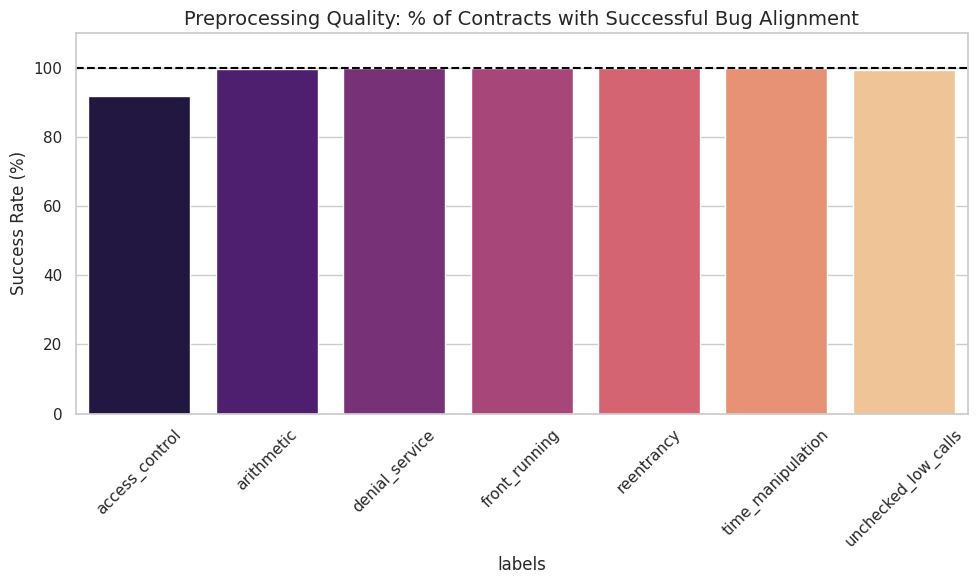

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_mapping_success(chunks_list, df_source):
    # Map which contract_ids have at least one positive chunk
    actual_vuln_ids = {c['contract_id'] for c in chunks_list if c['label'] == 1}

    # Filter source DF to only vulnerable contracts
    df_v = df_source[df_source['is_vulnerable'] == True].copy()
    df_v['mapping_successful'] = df_v['contract_id'].isin(actual_vuln_ids)

    # Calculate success rate per label
    success_stats = df_v.groupby('labels')['mapping_successful'].mean().reset_index()
    success_stats['mapping_successful'] *= 100  # Convert to percentage

    plt.figure(figsize=(10, 6))
    sns.barplot(data=success_stats, x='labels', y='mapping_successful', palette='magma')
    plt.axhline(100, color='black', linestyle='--')
    plt.title('Preprocessing Quality: % of Contracts with Successful Bug Alignment', fontsize=14)
    plt.ylabel('Success Rate (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 110)
    plt.tight_layout()
    plt.show()

plot_mapping_success(train_chunks_list, train_df_final)

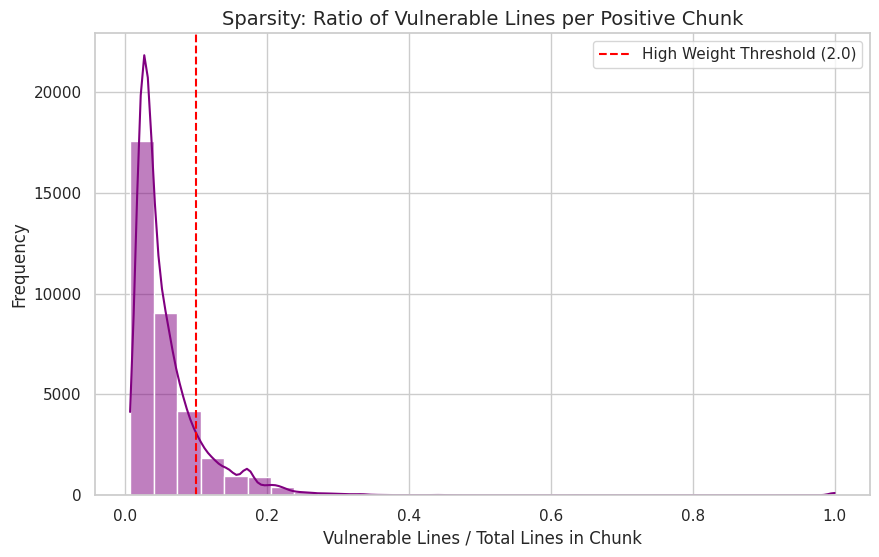

In [ ]:
def plot_sparsity_distribution(chunks_list):
    # Calculate ratio of positive lines for all positive chunks
    ratios = [
        sum(c['chunk_line_labels']) / len(c['chunk_line_labels'])
        for c in chunks_list if c['label'] == 1
    ]

    plt.figure(figsize=(10, 6))
    sns.histplot(ratios, bins=30, kde=True, color='purple')

    # Annotate your current weight thresholds
    plt.axvline(0.1, color='red', linestyle='--', label='High Weight Threshold (2.0)')
    plt.title('Sparsity: Ratio of Vulnerable Lines per Positive Chunk', fontsize=14)
    plt.xlabel('Vulnerable Lines / Total Lines in Chunk')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_sparsity_distribution(train_chunks_list)

/tmp/ipykernel_38256/2439023647.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=chunk_frequencies, palette='viridis')


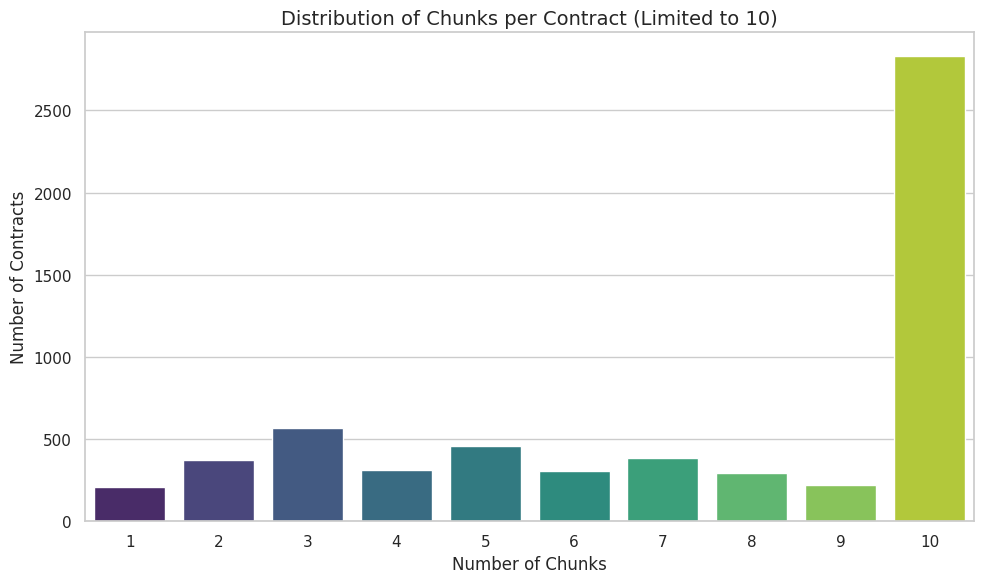

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def plot_chunk_counts(chunks_list, limit=10):
    # Count chunks per contract ID
    counts = Counter([c['contract_id'] for c in chunks_list])

    # Filter: only keep frequencies that are <= your limit
    chunk_frequencies = [freq for freq in counts.values() if freq <= limit]

    plt.figure(figsize=(10, 6))
    # Using 'viridis' palette; showing the distribution of contracts within the limit
    sns.countplot(x=chunk_frequencies, palette='viridis')

    plt.title(f'Distribution of Chunks per Contract (Limited to {limit})', fontsize=14)
    plt.xlabel('Number of Chunks')
    plt.ylabel('Number of Contracts')
    plt.tight_layout()
    plt.show()

plot_chunk_counts(train_chunks_list, limit=10)

--- Mean Vulnerability Density per Class ---
              Category   Density
0    time_manipulation  0.065560
1           arithmetic  0.060770
2       denial_service  0.060487
3           reentrancy  0.059736
4       access_control  0.056888
5  unchecked_low_calls  0.055632
6        front_running  0.051876


/tmp/ipykernel_38256/1887869007.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Density', y='Category', data=class_means, palette='viridis')


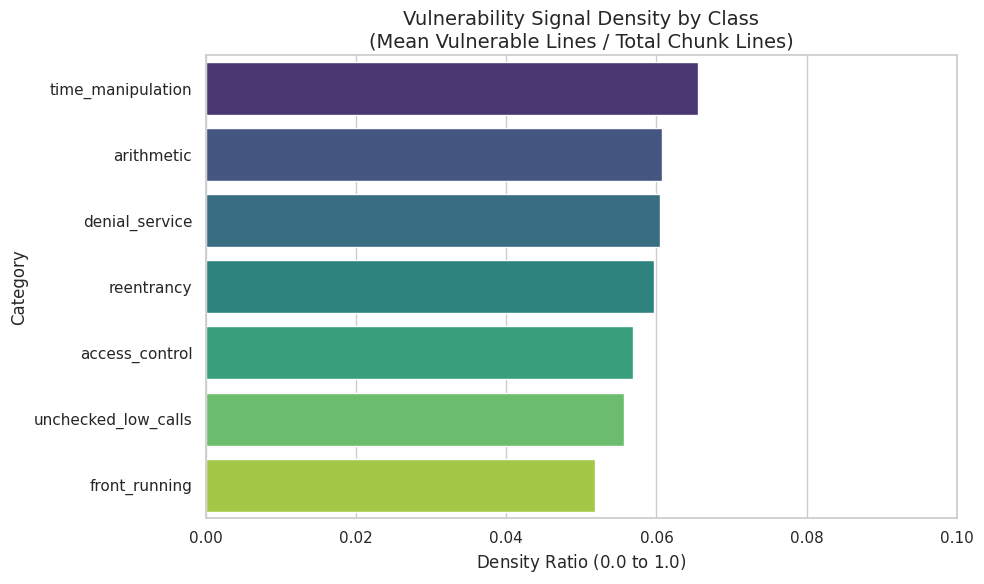

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def log_class_density(chunks_list, df_source):
    # 1. Create lookup for contract categories
    id_to_label = df_source.set_index('contract_id')['labels'].to_dict()

    # 2. Extract ratios for all positive chunks
    records = []
    for chunk in chunks_list:
        if chunk['label'] == 1:  # Only look at chunks containing a vulnerability
            cat = id_to_label.get(chunk['contract_id'], "Unknown")

            num_vuln = sum(chunk['chunk_line_labels'])
            total_ln = len(chunk['chunk_line_labels'])
            ratio = num_vuln / max(total_ln, 1)

            records.append({'Category': cat, 'Density': ratio})

    # 3. Aggregate results
    density_df = pd.DataFrame(records)
    class_means = density_df.groupby('Category')['Density'].mean().sort_values(ascending=False).reset_index()

    print("--- Mean Vulnerability Density per Class ---")
    print(class_means)


    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.barplot(x='Density', y='Category', data=class_means, palette='viridis')

    plt.title('Vulnerability Signal Density by Class\n(Mean Vulnerable Lines / Total Chunk Lines)', fontsize=14)
    plt.xlabel('Density Ratio ($0.0$ to $1.0$)', fontsize=12)
    plt.xlim(0, 0.1) # Zoom in to show the differences clearly
    plt.tight_layout()
    plt.savefig('final_density_results.png', dpi=300)

# Run the analysis
log_class_density(train_chunks_list, df_clean)

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_chunk_distribution(chunks_list, split_name="Train"):
    # Extract labels and contract IDs from the chunk dictionaries
    labels = [c['label'] for c in chunks_list]
    contract_ids = [c['contract_id'] for c in chunks_list]

    counts = Counter(labels)
    total_chunks = len(labels)
    unique_contracts = len(set(contract_ids))

    print(f"--- {split_name} Set Analysis ---")
    print(f"Total Chunks generated: {total_chunks}")
    print(f"Total Unique Contracts represented: {unique_contracts}")
    print(f"Average chunks per contract: {total_chunks/unique_contracts:.2f}")

    for label, count in counts.items():
        label_name = "Vulnerable (1)" if label == 1 else "Safe (0)"
        percentage = (count / total_chunks) * 100
        print(f"  - {label_name}: {count} chunks ({percentage:.2f}%)")
    print("\n" + "="*40 + "\n")

# Execute verification for all splits
analyze_chunk_distribution(train_chunks_list, "Training")
analyze_chunk_distribution(val_chunks_list, "Validation")
analyze_chunk_distribution(test_chunks_list, "Test")

--- Training Set Analysis ---
Total Chunks generated: 60620
Total Unique Contracts represented: 6776
Average chunks per contract: 8.95
  - Vulnerable (1): 35216 chunks (58.09%)
  - Safe (0): 25404 chunks (41.91%)


--- Validation Set Analysis ---
Total Chunks generated: 33201
Total Unique Contracts represented: 2698
Average chunks per contract: 12.31
  - Safe (0): 18350 chunks (55.27%)
  - Vulnerable (1): 14851 chunks (44.73%)


--- Test Set Analysis ---
Total Chunks generated: 33614
Total Unique Contracts represented: 2698
Average chunks per contract: 12.46
  - Vulnerable (1): 14550 chunks (43.29%)
  - Safe (0): 19064 chunks (56.71%)




In [ ]:
set(val_df.contract_id).intersection(set(test_df.contract_id))

set()

In [ ]:
def inspect_random_contract(df_source, chunks_list, n_examples=3):
    import random

    contract_ids = list(set(c["contract_id"] for c in chunks_list))
    sampled_ids = random.sample(contract_ids, min(n_examples, len(contract_ids)))

    for cid in sampled_ids:
        print("\n" + "=" * 80)
        print(f"CONTRACT ID: {cid}")
        print("=" * 80)

        # original row
        row = df_source[df_source["contract_id"] == cid].iloc[0]

        print("\n--- Contract-level info ---")
        print("is_vulnerable:", row["is_vulnerable"])
        print("label type:", row["labels"])
        print("raw vuln lines:", row["lines"])

        source_lines = str(row["source_code"]).split("\n")

        # all chunks for this contract
        contract_chunks = [
            c for c in chunks_list
            if c["contract_id"] == cid
        ]

        print(f"\nTotal chunks: {len(contract_chunks)}")

        for idx, chunk in enumerate(contract_chunks):
            print("\n" + "-" * 60)
            print(f"CHUNK {idx}")
            print("-" * 60)

            print("Chunk label:", chunk["label"])
            print("Contract label:", chunk["contract_label"])
            print("Weight:", chunk["weight"])

            # reconstruct approximate line span
            line_labels = chunk["chunk_line_labels"]
            num_lines = len(line_labels)

            print("Chunk num lines:", num_lines)
            print("Positive line labels:", sum(line_labels))

            print("\nchunk_line_labels:")
            print(line_labels[:80])

            print("\nDecoded text preview:")

            decoded = tokenizer.decode(
                chunk["anchor_input_ids"],
                skip_special_tokens=True
            )

            print(decoded[:1500])  # preview only
            print("\n")

inspect_random_contract(train_df_final, train_chunks_list, n_examples=5)


CONTRACT ID: 37246

--- Contract-level info ---
is_vulnerable: True
label type: denial_service
raw vuln lines: [41, 45]

Total chunks: 1

------------------------------------------------------------
CHUNK 0
------------------------------------------------------------
Chunk label: 1
Contract label: 1
Weight: 1.5
Chunk num lines: 32
Positive line labels: 2

chunk_line_labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]

Decoded text preview:



























 

contract SafePromo {

	address public owner;
	event Transfer(address indexed _from, address indexed _to, uint256 _value);

	function SafePromo() public {

		owner = msg.sender;

	}

	function promo(address[] _recipients) public {

		require(msg.sender == owner);

		for(uint256 i = 0; i < _recipients.length; i++){

			_recipients[i].transfer(7777777777);
			emit Transfer(address(this), _recipients[i], 77777777777);

		}

	}

	function() public payable{ }

}



CONTRACT

In [ ]:
from collections import defaultdict

def validate_processed_data(processed_data):
    # Initialize trackers for dataset health metrics
    stats = {
        "total_chunks": 0,
        "positive_chunks": 0,
        "negative_chunks": 0,
        "label_mismatch": 0,
        "weight_mismatch": 0,
        "clean_contract_with_positive_chunk": 0,
        "vuln_contract_missing_positive_chunk": 0,
    }

    # Track contract-level integrity to ensure bug alignment
    contract_summary = defaultdict(lambda: {
        "contract_label": None,
        "has_positive_chunk": False
    })

    bad_examples = []

    for chunk in processed_data:
        stats["total_chunks"] += 1

        contract_id = chunk["contract_id"]
        contract_label = chunk["contract_label"]
        label = chunk["label"]
        weight = chunk["weight"]
        line_labels = chunk["chunk_line_labels"]

        # Calculate expected values based on ground truth
        positives = sum(line_labels)
        positive_ratio = positives / max(len(line_labels), 1)

        # Verify binary label logic
        expected_label = 1 if positives > 0 else 0
        if label != expected_label:
            stats["label_mismatch"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": f"label mismatch: expected {expected_label}, got {label}"
            })

        # Verify density-based loss weights
        expected_weight = 1.0
        if positive_ratio >= 0.1:
            expected_weight = 2.0
        elif positive_ratio > 0:
            expected_weight = 1.5

        # Fix: Using float comparison for robustness
        if abs(weight - expected_weight) > 1e-5:
            stats["weight_mismatch"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": f"weight mismatch: expected {expected_weight}, got {weight}"
            })

        # Update running stats and contract summaries
        if label == 1:
            stats["positive_chunks"] += 1
            contract_summary[contract_id]["has_positive_chunk"] = True
        else:
            stats["negative_chunks"] += 1

        contract_summary[contract_id]["contract_label"] = contract_label

    # --- Contract-Level Integrity Checks ---
    # Ensures that safe contracts stay safe and vulnerable ones have data
    for contract_id, info in contract_summary.items():
        c_label = info["contract_label"]
        has_pos = info["has_positive_chunk"]

        # Check for "Ghost" bugs in clean contracts
        if c_label == 0 and has_pos:
            stats["clean_contract_with_positive_chunk"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": "CRITICAL: Clean contract contains a positive chunk"
            })

        # Check for missing signal in vulnerable contracts
        if c_label == 1 and not has_pos:
            stats["vuln_contract_missing_positive_chunk"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": "WARNING: Vulnerable contract has no positive chunks included"
            })

    return stats, bad_examples

In [ ]:
def debug_alignment(row):
    source_lines = row['cleaned_contract'].split("\n")
    vuln_lines = normalize_vuln_lines(row['lines'], len(source_lines))

    print("Contract ID:", row['contract_id'])
    print("Total lines:", len(source_lines))
    print("Raw labels:", row['lines'])
    print("Valid labels:", vuln_lines)

    for v in list(vuln_lines)[:5]:
        print(f"\n--- Line {v} ---")
        print(source_lines[v])

import random

vuln_df = df_clean[df_clean['is_vulnerable'] == True]

sample_rows = vuln_df.sample(n=5, random_state=42)

for _, row in sample_rows.iterrows():
    debug_alignment(row)

Contract ID: 17761
Total lines: 205
Raw labels: [41, 45, 39]
Valid labels: {40, 44, 38}

--- Line 40 ---
    return c;

--- Line 44 ---
contract ERC20Basic {

--- Line 38 ---
    uint256 c = a + b;
Contract ID: 46557
Total lines: 58
Raw labels: [16, 46, 55]
Valid labels: {45, 54, 15}

--- Line 45 ---
    function set(bytes32 goeureka_audit_ref, string reference) 

--- Line 54 ---
        return records[goeureka_audit_ref].reference;

--- Line 15 ---
contract SimpleAudit {
Contract ID: 6224
Total lines: 312
Raw labels: [251, 219]
Valid labels: {218, 250}

--- Line 218 ---
        totalSupply += mintedAmount;

--- Line 250 ---
        totalSupply -= _value;                               
Contract ID: 4875
Total lines: 465
Raw labels: [57]
Valid labels: {56}

--- Line 56 ---
  
Contract ID: 36844
Total lines: 222
Raw labels: [104, 218, 200]
Valid labels: {217, 199, 103}

--- Line 217 ---
     

--- Line 199 ---
    function approveAndCall(address spender, uint tokens, bytes data) public r

## 6. Final Export
The processed data is saved as PyTorch tensors (`.pt`) containing input IDs, attention masks, and chunk-level labels for use in the model training notebook.

In [ ]:
import torch
TARGET_DIR = '/content/drive/My Drive/CPSC440_project/data/'
torch.save(train_chunks_list, TARGET_DIR+"train_chunks.pt")
torch.save(val_chunks_list, TARGET_DIR+"val_chunks.pt")
torch.save(test_chunks_list, TARGET_DIR+"test_chunks.pt")
torch.save(test_chunks_transformed, TARGET_DIR+"test_chunks_eval.pt")

Subsetting to 15000 chunks

In [ ]:
import torch
import random
import os
from collections import defaultdict

# -------------------------
# CONFIG
# -------------------------
SEED = 42
TARGET_CONTRACTS = 15000
MAX_CHUNKS_PER_CONTRACT = 10

TARGET_DIR = '/content/drive/My Drive/CPSC440_project/data/'

random.seed(SEED)

# -------------------------
# LOAD DATA
# -------------------------
full_train_list = torch.load(
    os.path.join(TARGET_DIR, "train_chunks.pt")
)

print(f"Total chunks loaded: {len(full_train_list)}")

contract_to_chunks = defaultdict(list)

for chunk in full_train_list:
    contract_to_chunks[chunk["contract_id"]].append(chunk)

print(f"Total contracts: {len(contract_to_chunks)}")

contract_labels = {}

for cid, chunks in contract_to_chunks.items():
    contract_labels[cid] = max(c["label"] for c in chunks)

pos_contracts = [c for c, y in contract_labels.items() if y == 1]
neg_contracts = [c for c, y in contract_labels.items() if y == 0]

print(f"Positive contracts: {len(pos_contracts)}")
print(f"Negative contracts: {len(neg_contracts)}")

random.shuffle(pos_contracts)
random.shuffle(neg_contracts)

total = len(pos_contracts) + len(neg_contracts)
pos_target = int(TARGET_CONTRACTS * (len(pos_contracts) / total))
neg_target = TARGET_CONTRACTS - pos_target

selected_contracts = (
    pos_contracts[:pos_target] +
    neg_contracts[:neg_target]
)

random.shuffle(selected_contracts)

print(f"Selected contracts: {len(selected_contracts)}")

stable_train_subset = []

for cid in selected_contracts:
    chunks = contract_to_chunks[cid]

    # cap large contracts
    if len(chunks) > MAX_CHUNKS_PER_CONTRACT:
        chunks = random.sample(chunks, MAX_CHUNKS_PER_CONTRACT)

    stable_train_subset.extend(chunks)

print(f"Final chunks in dataset: {len(stable_train_subset)}")

save_path = os.path.join(
    TARGET_DIR,
    "train_chunks_subset.pt"
)

torch.save(stable_train_subset, save_path)

print(f"Saved to: {save_path}")

Total chunks loaded: 60620
Total contracts: 6776
Positive contracts: 5131
Negative contracts: 1645
Selected contracts: 6776
Final chunks in dataset: 51617
Saved to: /content/drive/My Drive/CPSC440_project/data/train_chunks_subset.pt


In [ ]:
sum(c["label"] for c in stable_train_subset) / len(stable_train_subset)

0.5078365654726156

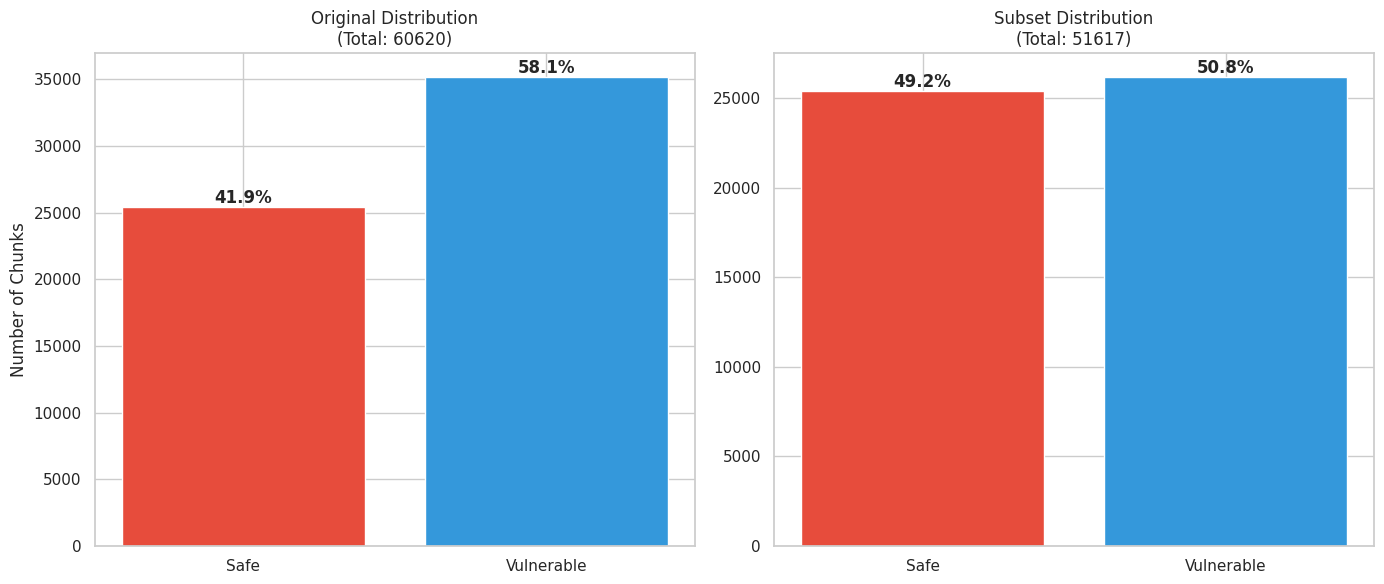

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_distribution_check(original_data, subset_data):
    # 1. Extract and count labels (0 = Safe, 1 = Vulnerable)
    # We use .item() if the labels were saved as tensors
    orig_labels = [int(item['label']) for item in original_data]
    sub_labels = [int(item['label']) for item in subset_data]

    orig_counts = Counter(orig_labels)
    sub_counts = Counter(sub_labels)

    # 2. Setup Side-by-Side Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['#3498db', '#e74c3c'] # Blue for Safe, Red for Vulnerable

    # Plot Original (35k)
    ax1.bar(orig_counts.keys(), orig_counts.values(), color=colors)
    ax1.set_title(f"Original Distribution\n(Total: {len(original_data)})")
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Safe', 'Vulnerable'])
    ax1.set_ylabel("Number of Chunks")

    # Plot Subset (15k)
    ax2.bar(sub_counts.keys(), sub_counts.values(), color=colors)
    ax2.set_title(f"Subset Distribution\n(Total: {len(subset_data)})")
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(['Safe', 'Vulnerable'])

    # 3. Add percentage labels on top of bars
    for i, ax in enumerate([ax1, ax2]):
        counts = orig_counts if i == 0 else sub_counts
        total = len(original_data) if i == 0 else len(subset_data)
        for label, count in counts.items():
            percentage = (count / total) * 100
            ax.text(label, count, f'{percentage:.1f}%',
                    ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig("data_distribution_consistency.png")
    plt.show()

# Run the check!
plot_distribution_check(full_train_list, stable_train_subset)